In [1]:
from utility import load_test_results, architecture_stats, sample_image

from NeuralNetwork import NeuralNetwork, torch

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.min_rows', 5000)
pd.set_option('display.max_rows', 5000)

{0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'E', 5: 'F', 6: 'G', 7: 'H', 8: 'I', 9: 'K', 10: 'L', 11: 'M', 12: 'N', 13: 'O', 14: 'P', 15: 'Q', 16: 'R', 17: 'S', 18: 'T', 19: 'U', 20: 'V', 21: 'W', 22: 'X', 23: 'Y'}


In [2]:
classifiers_dict, all_results = load_test_results("Classifier_3")

In [3]:
classifiers_dict

{0: "Classifier_3 (n_neurons_molt_factor=0.6, do_dropout=['Conv2'])"}

In [4]:
all_results.head(10)

,test_id,architecture_id,n_neurons_molt_factor,do_dropout,lr,batch_size,patience,data_augmentation_perc,test_accuracies,test_times,train_times
0,0,0,0.6,['Conv2'],0.0005,32,5,0.00,0.981735,0.080683,30.840531
1,1,0,0.6,['Conv2'],0.0005,32,5,0.25,0.972253,0.091232,7.001711
2,2,0,0.6,['Conv2'],0.0005,32,5,0.50,0.987591,0.080886,14.667440
3,3,0,0.6,['Conv2'],0.0005,32,5,0.75,0.995259,0.080821,10.189537
4,4,0,0.6,['Conv2'],0.0005,32,10,0.00,0.994283,0.081447,30.537555
5,5,0,0.6,['Conv2'],0.0005,32,10,0.25,0.994980,0.081631,42.559637
6,6,0,0.6,['Conv2'],0.0005,32,10,0.50,0.987451,0.082619,55.975638
7,7,0,0.6,['Conv2'],0.0005,32,10,0.75,0.993028,0.081127,26.303567
8,8,0,0.6,['Conv2'],0.0005,32,15,0.00,0.991913,0.082033,30.646908
9,9,0,0.6,['Conv2'],0.0005,32,15,0.25,0.995538,0.081801,46.844007


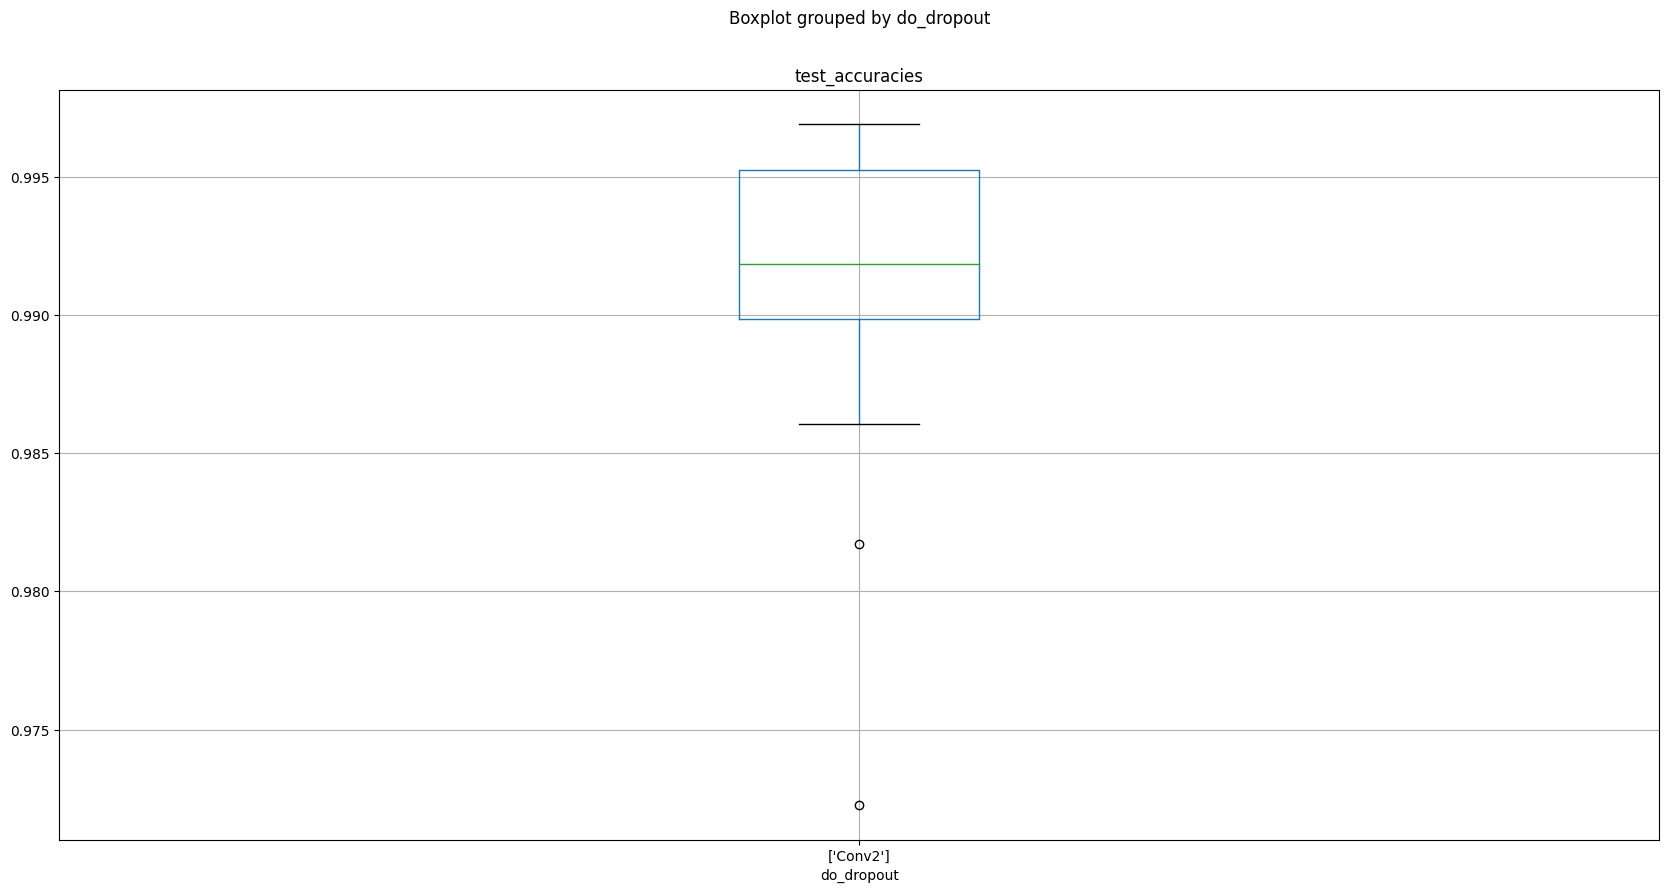

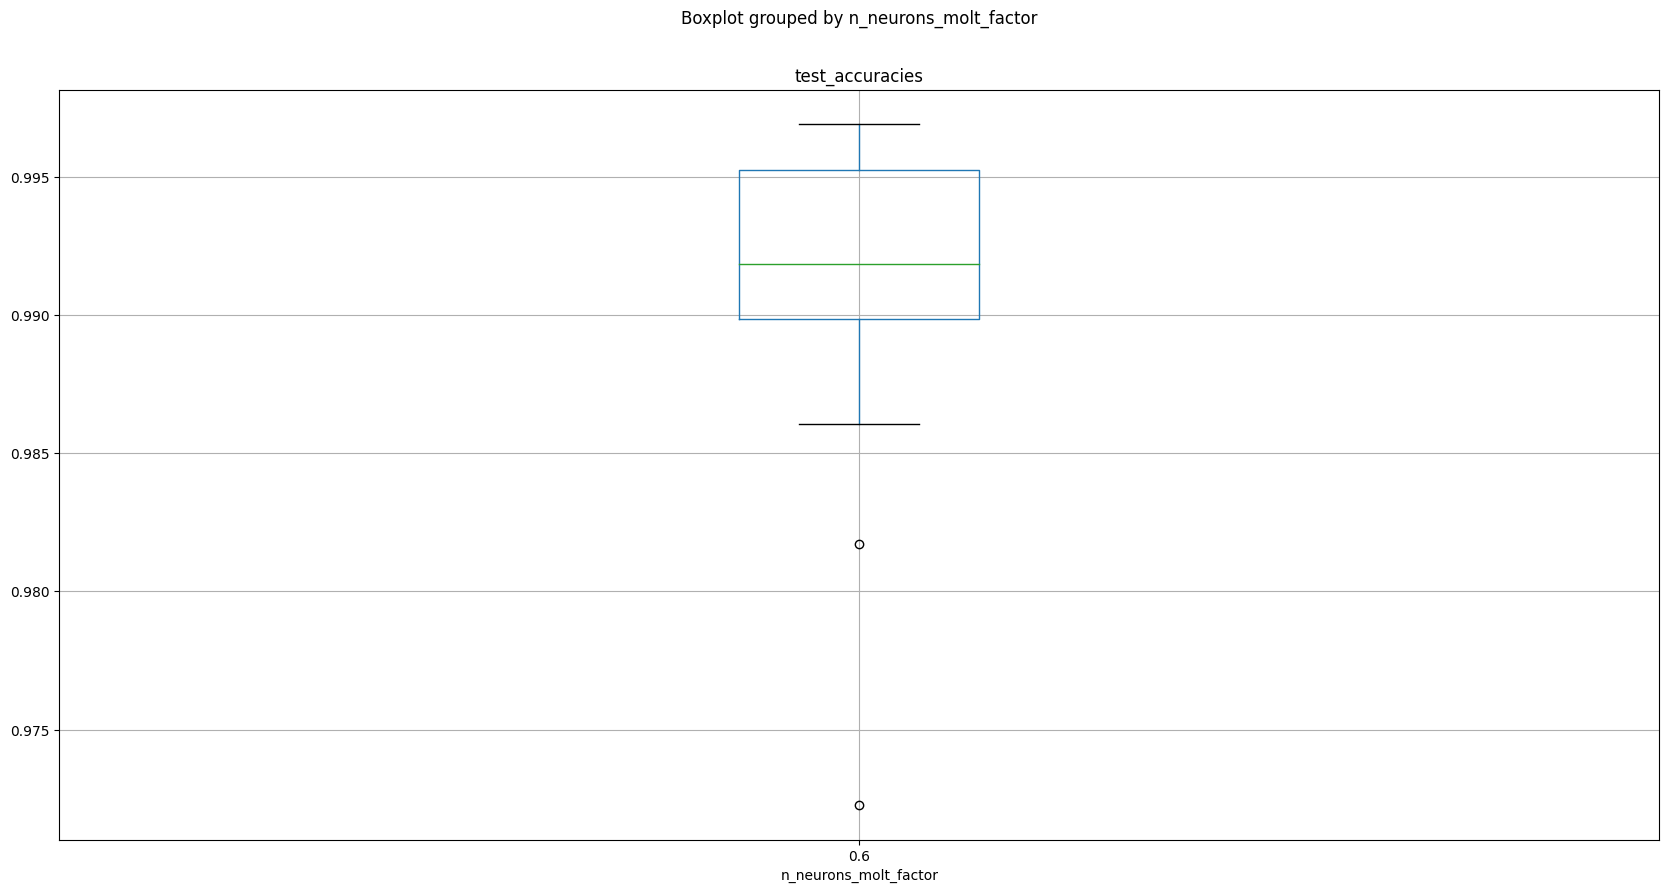

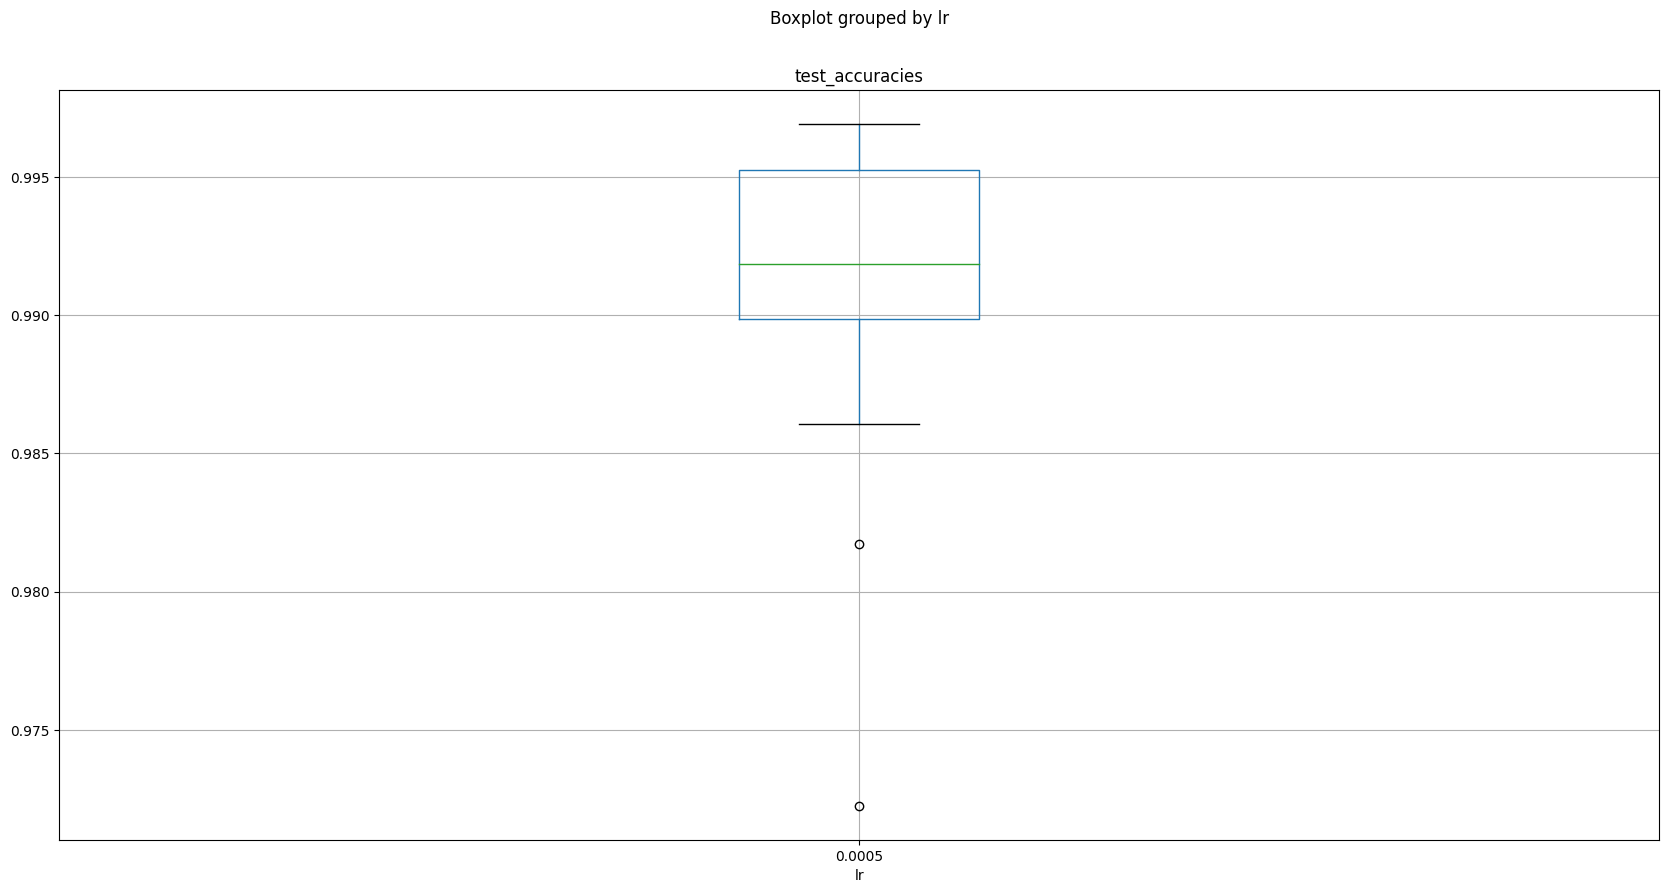

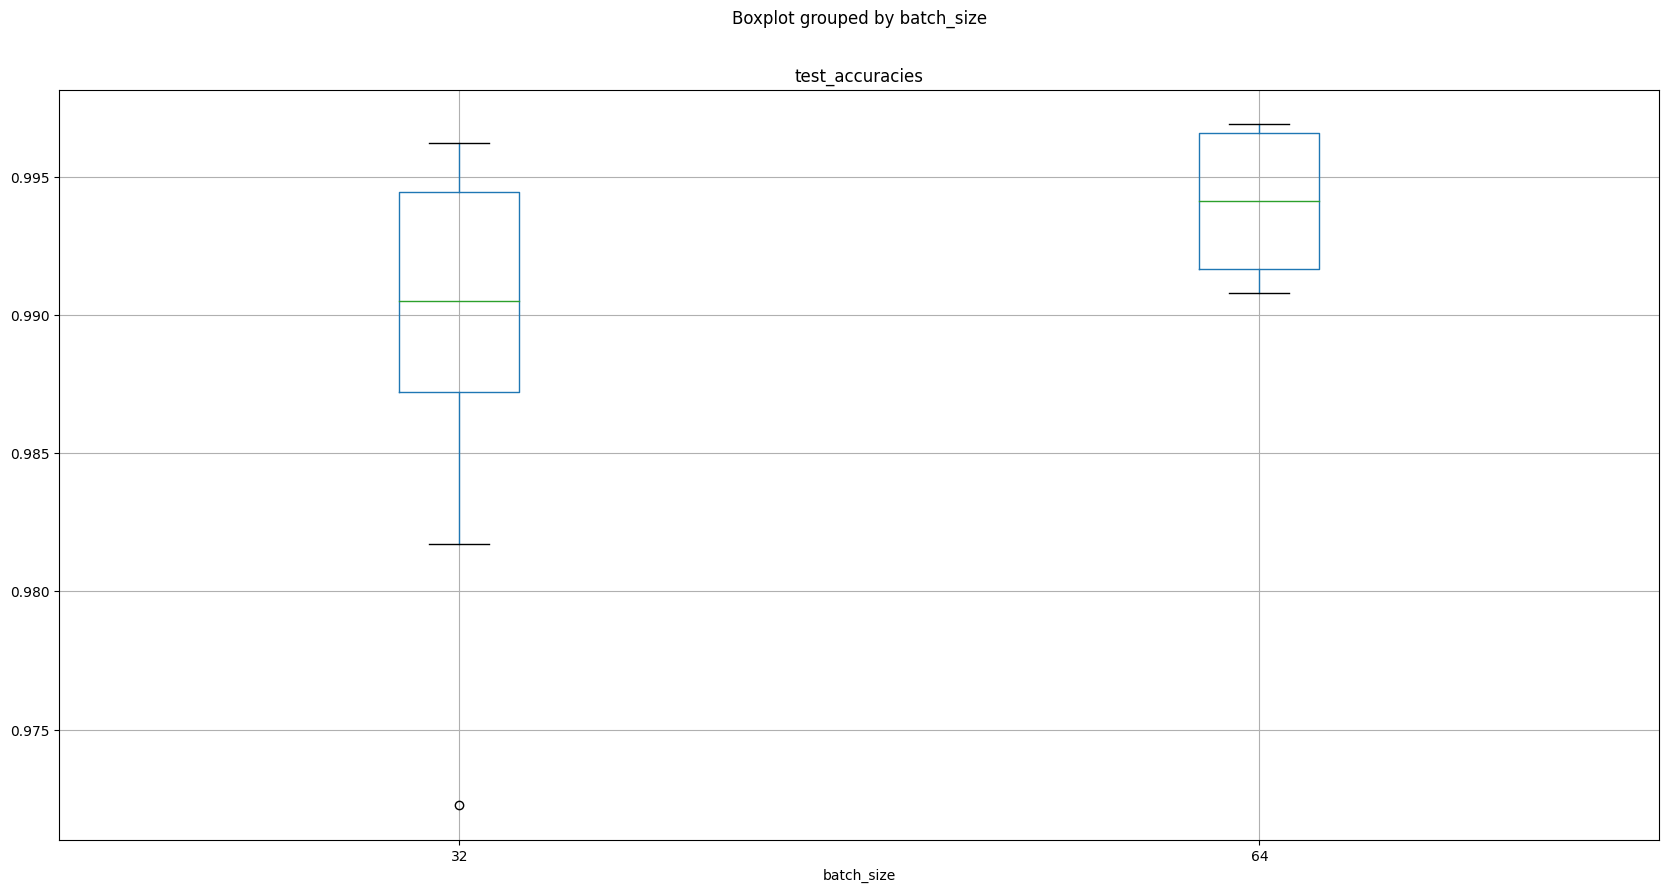

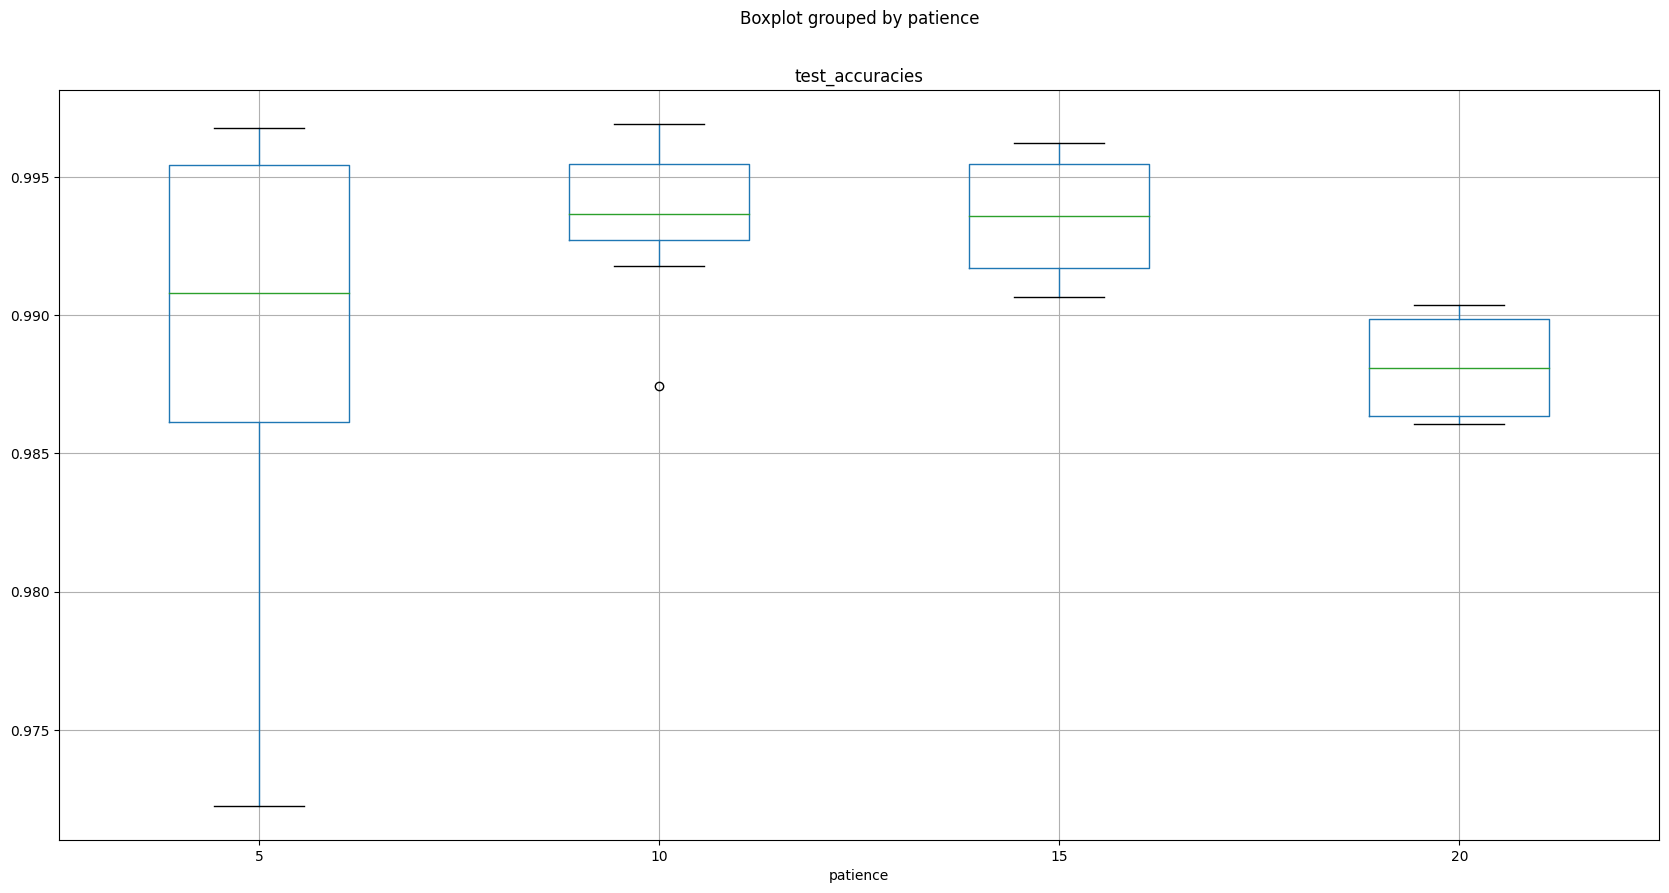

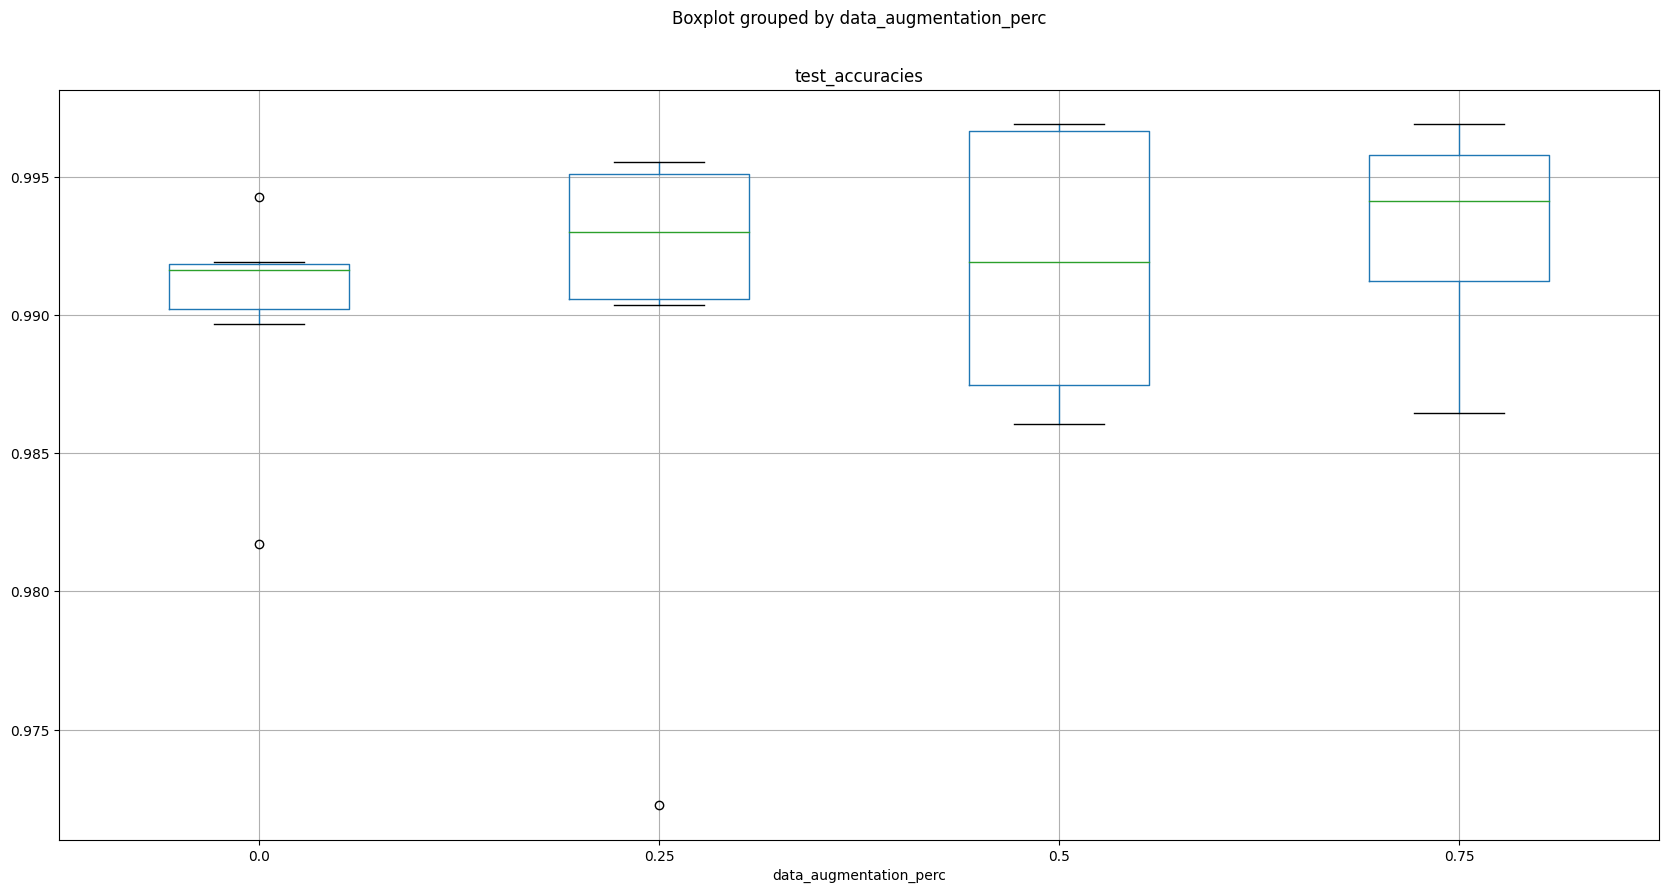

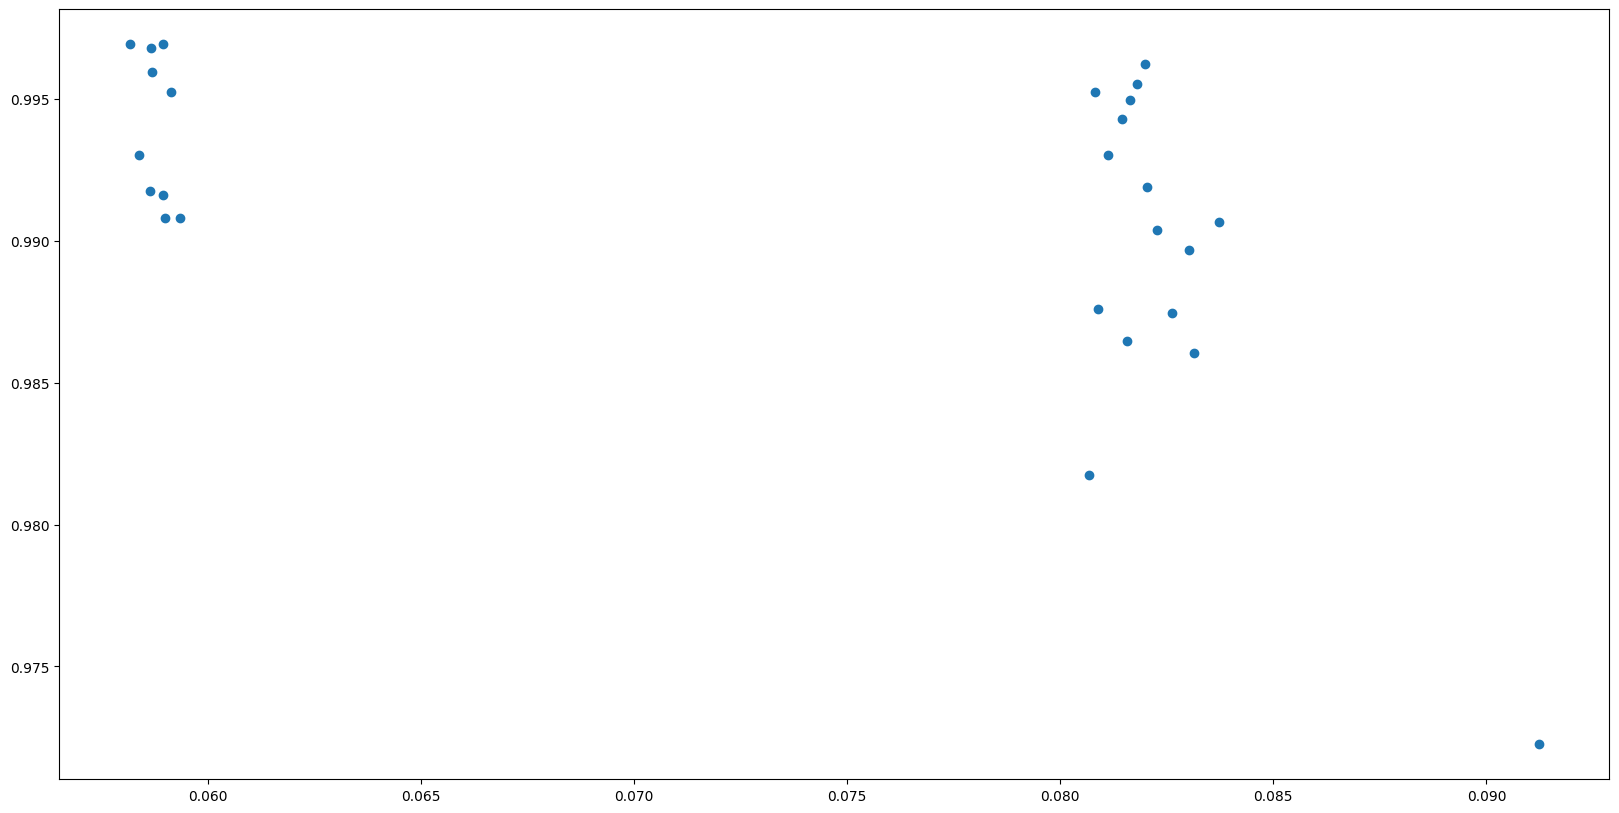

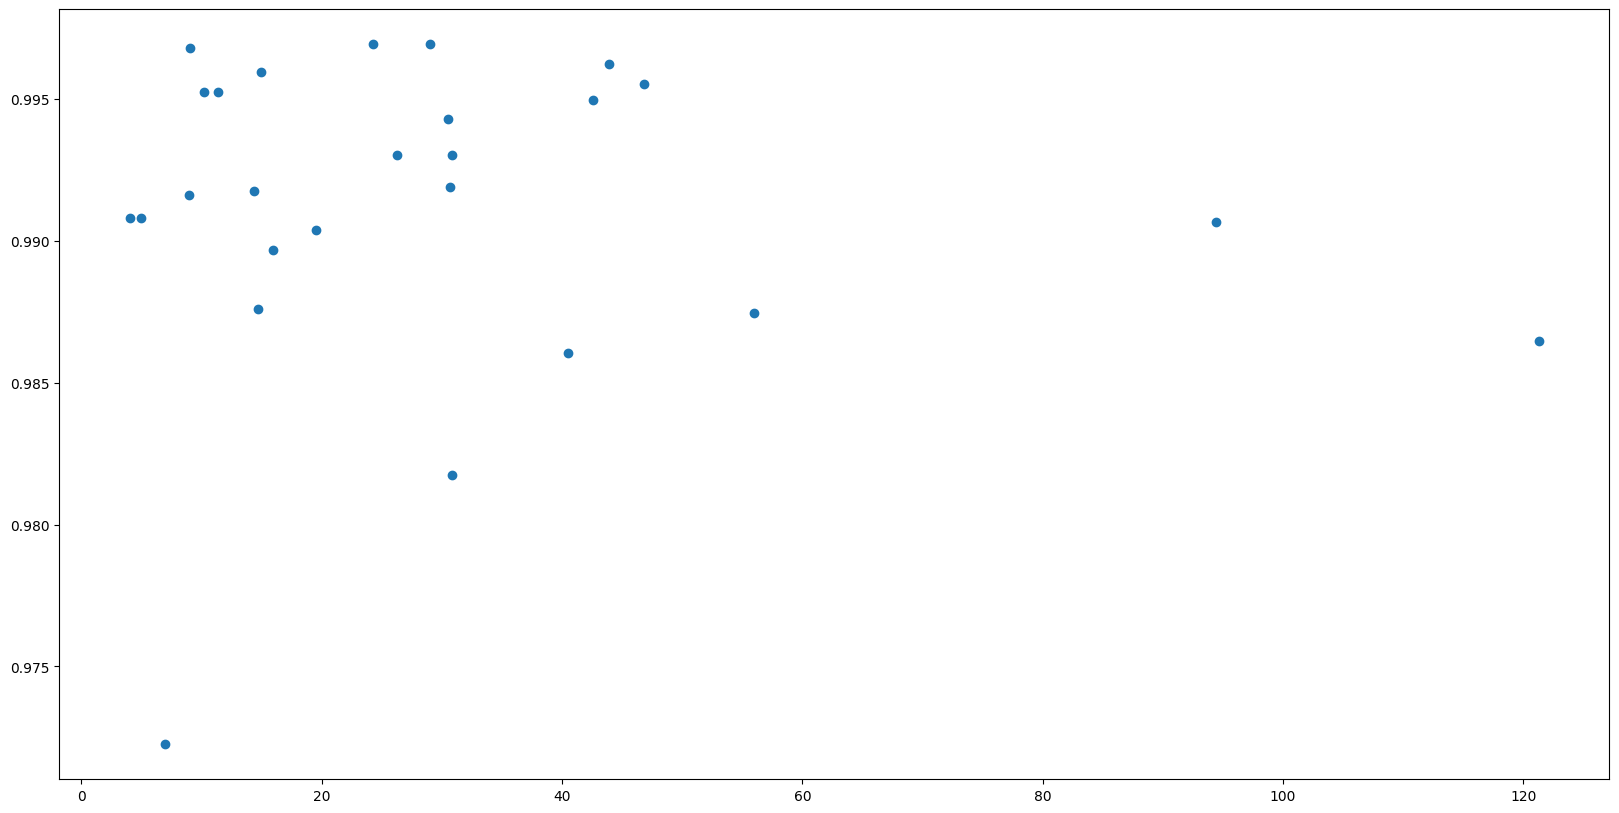

In [5]:
def plot_hyper():
    
    fig,ax=plt.subplots(figsize=(20,10))
    prova = all_results.sort_values(by="do_dropout")
    prova.boxplot(column =["test_accuracies"], by="do_dropout", ax=ax)
    
    fig,ax=plt.subplots(figsize=(20,10))
    all_results.boxplot(column =["test_accuracies"], by="n_neurons_molt_factor", ax=ax)
    
    fig,ax=plt.subplots(figsize=(20,10))
    all_results.boxplot(column =["test_accuracies"], by="lr", ax=ax)
    
    fig,ax=plt.subplots(figsize=(20,10))
    all_results.boxplot(column =["test_accuracies"], by="batch_size", ax=ax)
    
    fig,ax=plt.subplots(figsize=(20,10))
    all_results.boxplot(column =["test_accuracies"], by="patience", ax=ax)
    
    fig,ax=plt.subplots(figsize=(20,10))
    all_results.boxplot(column =["test_accuracies"], by="data_augmentation_perc", ax=ax)
    
    fig,ax=plt.subplots(figsize=(20,10))
    ax.scatter(all_results["test_times"], all_results["test_accuracies"])
    
    fig,ax=plt.subplots(figsize=(20,10))
    ax.scatter(all_results["train_times"], all_results["test_accuracies"])

plot_hyper()

In [6]:
all_results.sort_values(by=['test_accuracies'], ascending=False).head(10)

,test_id,architecture_id,n_neurons_molt_factor,do_dropout,lr,batch_size,patience,data_augmentation_perc,test_accuracies,test_times,train_times
23,23,0,0.6,['Conv2'],0.0005,64,10,0.75,0.996933,0.058945,24.265854
22,22,0,0.6,['Conv2'],0.0005,64,10,0.50,0.996933,0.058164,29.053225
18,18,0,0.6,['Conv2'],0.0005,64,5,0.50,0.996793,0.058658,9.011681
10,10,0,0.6,['Conv2'],0.0005,32,15,0.50,0.996235,0.081994,43.936866
19,19,0,0.6,['Conv2'],0.0005,64,5,0.75,0.995956,0.058689,14.954333
9,9,0,0.6,['Conv2'],0.0005,32,15,0.25,0.995538,0.081801,46.844007
25,25,0,0.6,['Conv2'],0.0005,64,15,0.25,0.995259,0.059131,11.333086
3,3,0,0.6,['Conv2'],0.0005,32,5,0.75,0.995259,0.080821,10.189537
5,5,0,0.6,['Conv2'],0.0005,32,10,0.25,0.994980,0.081631,42.559637
4,4,0,0.6,['Conv2'],0.0005,32,10,0.00,0.994283,0.081447,30.537555


In [7]:
n_high_accuracy_architectures = len(all_results[all_results["test_accuracies"]==all_results["test_accuracies"].max()])
n_high_accuracy_architectures

2

In [8]:
high_accuracy_architectures = all_results.sort_values(by=['test_accuracies'], ascending=False).head(n_high_accuracy_architectures)["architecture_id"].unique()
high_accuracy_architectures

array([0])

In [9]:
for model in high_accuracy_architectures:
    architecture_stats(all_results, classifiers_dict, model)

Stats for architecture: Classifier_3 (n_neurons_molt_factor=0.6, do_dropout=['Conv2']) (id: 0)
mean accuracy: 0.9913 with standard error: 0.0055

worst accuracy: 0.9723 with hyperparameters:
test_id                          1
lr                          0.0005
batch_size                      32
patience                         5
data_augmentation_perc        0.25
test_times                0.091232
train_times               7.001711
Name: 1, dtype: object 

best accuracy: 0.9969 with hyperparameters:
test_id                          22
lr                           0.0005
batch_size                       64
patience                         10
data_augmentation_perc          0.5
test_times                 0.058164
train_times               29.053225
Name: 22, dtype: object 



Loaded model: Classifier_3 (n_neurons_molt_factor=0.6, do_dropout=['Conv2'])_test_23


Architecture:
name: Classifier_3 (n_neurons_molt_factor=0.6, do_dropout=['Conv2'])
Layer (type:depth-idx)                   Output Shape              Param #
├─Sequential: 1-1                        [-1, 32, 12, 12]          --
|    └─Conv2d: 2-1                       [-1, 32, 24, 24]          832
|    └─MaxPool2d: 2-2                    [-1, 32, 12, 12]          --
|    └─ReLU: 2-3                         [-1, 32, 12, 12]          --
├─Sequential: 1-2                        [-1, 64, 4, 4]            --
|    └─Conv2d: 2-4                       [-1, 64, 8, 8]            51,264
|    └─MaxPool2d: 2-5                    [-1, 64, 4, 4]            --
|    └─ReLU: 2-6                         [-1, 64, 4, 4]            --
|    └─Dropout: 2-7                      [-1, 64, 4, 4]            --
├─Sequential: 1-3                        [-1, 128, 1, 1]           --
|    └─Conv2d: 2-8                       [-1, 128,

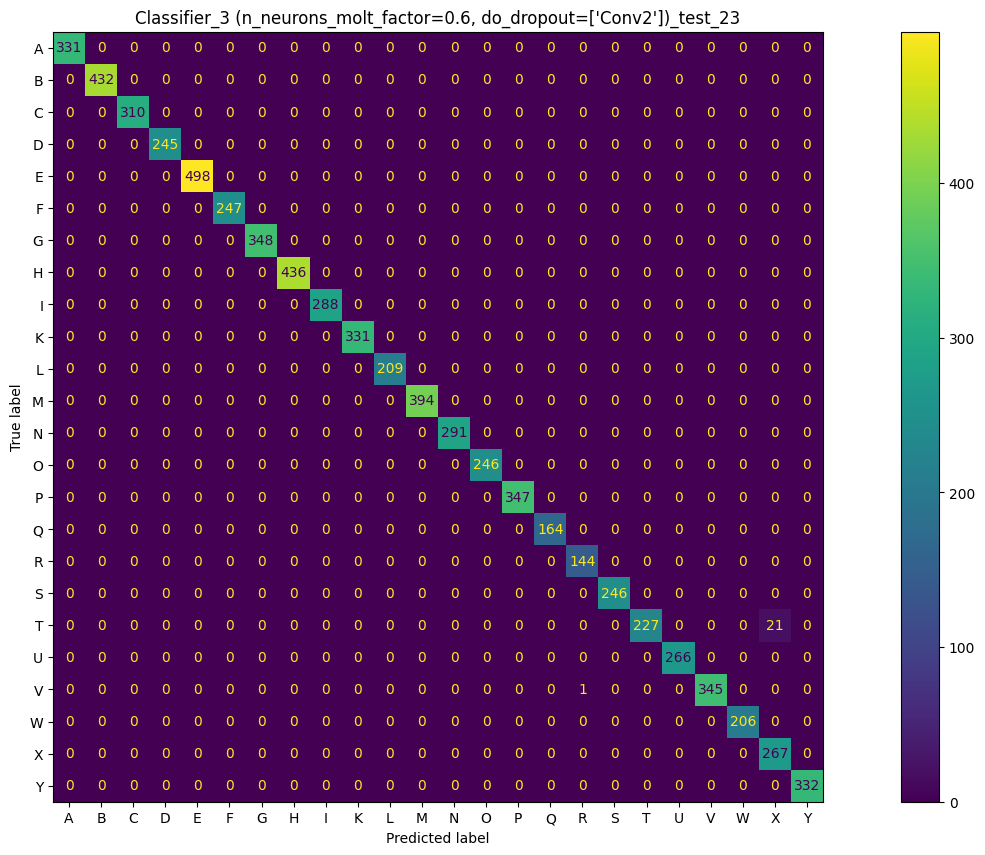

WRONG PREDICTIONS:


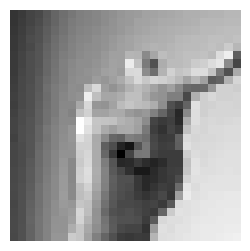

true response: T
predicted:


{'A': 0.0,
 'B': 0.0,
 'C': 0.0,
 'D': 0.0,
 'E': 0.0,
 'F': 0.0,
 'G': 1e-04,
 'H': 0.0,
 'I': 0.0,
 'K': 0.0,
 'L': 0.0,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 0.0,
 'Q': 0.0,
 'R': 0.0,
 'S': 0.0,
 'T': 0.0187,
 'U': 0.0,
 'V': 0.0,
 'W': 0.0,
 'X': 0.9812,
 'Y': 0.0}

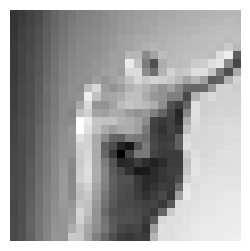

true response: T
predicted:


{'A': 0.0,
 'B': 0.0,
 'C': 0.0,
 'D': 0.0,
 'E': 0.0,
 'F': 0.0,
 'G': 0.0,
 'H': 0.0,
 'I': 0.0,
 'K': 0.0,
 'L': 0.0,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 0.0,
 'Q': 0.0,
 'R': 0.0,
 'S': 0.0,
 'T': 0.0022,
 'U': 0.0,
 'V': 0.0,
 'W': 0.0,
 'X': 0.9978,
 'Y': 0.0}

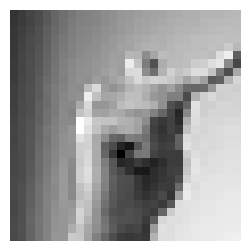

true response: T
predicted:


{'A': 0.0,
 'B': 0.0,
 'C': 0.0,
 'D': 0.0,
 'E': 0.0,
 'F': 0.0,
 'G': 0.0,
 'H': 0.0,
 'I': 0.0,
 'K': 0.0,
 'L': 0.0,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 0.0,
 'Q': 0.0,
 'R': 0.0,
 'S': 0.0,
 'T': 0.0048,
 'U': 0.0,
 'V': 0.0,
 'W': 0.0,
 'X': 0.9951,
 'Y': 0.0}

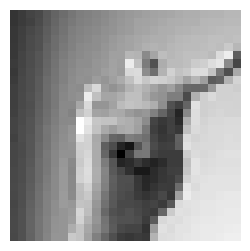

true response: T
predicted:


{'A': 0.0,
 'B': 0.0,
 'C': 0.0,
 'D': 0.0,
 'E': 0.0,
 'F': 0.0,
 'G': 0.0,
 'H': 0.0,
 'I': 0.0,
 'K': 0.0,
 'L': 0.0,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 0.0,
 'Q': 0.0,
 'R': 0.0,
 'S': 0.0,
 'T': 0.0093,
 'U': 0.0,
 'V': 0.0,
 'W': 0.0,
 'X': 0.9907,
 'Y': 0.0}

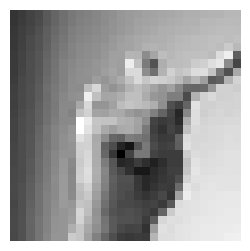

true response: T
predicted:


{'A': 0.0,
 'B': 0.0,
 'C': 0.0,
 'D': 0.0,
 'E': 0.0,
 'F': 0.0,
 'G': 0.0,
 'H': 0.0,
 'I': 0.0,
 'K': 0.0,
 'L': 0.0,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 0.0,
 'Q': 0.0,
 'R': 0.0,
 'S': 0.0,
 'T': 0.0009,
 'U': 0.0,
 'V': 0.0,
 'W': 0.0,
 'X': 0.9991,
 'Y': 0.0}

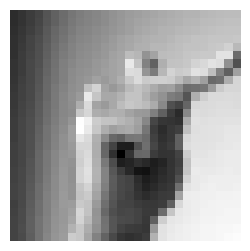

true response: T
predicted:


{'A': 0.0,
 'B': 0.0,
 'C': 0.0,
 'D': 0.0,
 'E': 0.0,
 'F': 0.0,
 'G': 0.0,
 'H': 0.0,
 'I': 0.0,
 'K': 0.0,
 'L': 0.0,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 0.0,
 'Q': 0.0,
 'R': 0.0,
 'S': 0.0,
 'T': 0.0064,
 'U': 0.0,
 'V': 0.0,
 'W': 0.0,
 'X': 0.9935,
 'Y': 0.0}

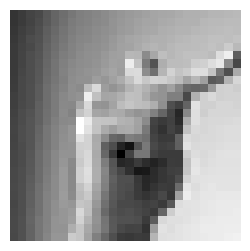

true response: T
predicted:


{'A': 0.0,
 'B': 0.0,
 'C': 0.0,
 'D': 0.0,
 'E': 0.0,
 'F': 0.0,
 'G': 0.0,
 'H': 0.0,
 'I': 0.0,
 'K': 0.0,
 'L': 0.0,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 0.0,
 'Q': 0.0,
 'R': 0.0,
 'S': 0.0,
 'T': 0.002,
 'U': 0.0,
 'V': 0.0,
 'W': 0.0,
 'X': 0.9979,
 'Y': 0.0}

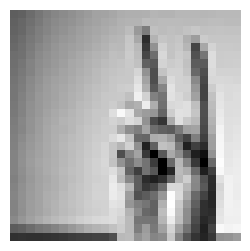

true response: V
predicted:


{'A': 0.0,
 'B': 0.0,
 'C': 0.0,
 'D': 0.0012,
 'E': 0.0,
 'F': 0.0,
 'G': 0.0,
 'H': 0.0,
 'I': 0.0,
 'K': 0.0,
 'L': 0.0,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 0.0,
 'Q': 0.0,
 'R': 0.8646,
 'S': 0.0,
 'T': 0.0,
 'U': 0.0,
 'V': 0.1341,
 'W': 0.0,
 'X': 0.0,
 'Y': 0.0}

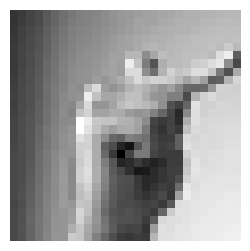

true response: T
predicted:


{'A': 0.0,
 'B': 0.0,
 'C': 0.0,
 'D': 0.0,
 'E': 0.0,
 'F': 0.0,
 'G': 1e-04,
 'H': 0.0,
 'I': 0.0,
 'K': 0.0,
 'L': 0.0,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 0.0,
 'Q': 0.0,
 'R': 0.0,
 'S': 0.0,
 'T': 0.0143,
 'U': 0.0,
 'V': 0.0,
 'W': 0.0,
 'X': 0.9856,
 'Y': 0.0}

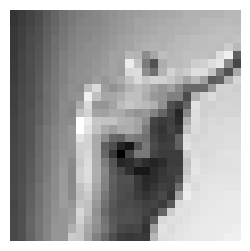

true response: T
predicted:


{'A': 0.0,
 'B': 0.0,
 'C': 0.0,
 'D': 0.0,
 'E': 0.0,
 'F': 0.0,
 'G': 0.0,
 'H': 0.0,
 'I': 0.0,
 'K': 0.0,
 'L': 0.0,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 0.0,
 'Q': 0.0,
 'R': 0.0,
 'S': 0.0,
 'T': 0.002,
 'U': 0.0,
 'V': 0.0,
 'W': 0.0,
 'X': 0.998,
 'Y': 0.0}

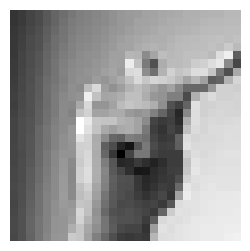

true response: T
predicted:


{'A': 0.0,
 'B': 0.0,
 'C': 0.0,
 'D': 0.0,
 'E': 0.0,
 'F': 0.0,
 'G': 0.0,
 'H': 0.0,
 'I': 0.0,
 'K': 0.0,
 'L': 0.0,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 0.0,
 'Q': 0.0,
 'R': 0.0,
 'S': 0.0,
 'T': 0.0029,
 'U': 0.0,
 'V': 0.0,
 'W': 0.0,
 'X': 0.997,
 'Y': 0.0}

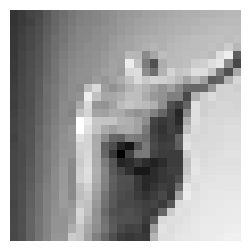

true response: T
predicted:


{'A': 0.0,
 'B': 0.0,
 'C': 0.0,
 'D': 0.0,
 'E': 0.0,
 'F': 0.0,
 'G': 0.0,
 'H': 0.0,
 'I': 0.0,
 'K': 0.0,
 'L': 0.0,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 0.0,
 'Q': 0.0,
 'R': 0.0,
 'S': 0.0,
 'T': 0.0034,
 'U': 0.0,
 'V': 0.0,
 'W': 0.0,
 'X': 0.9966,
 'Y': 0.0}

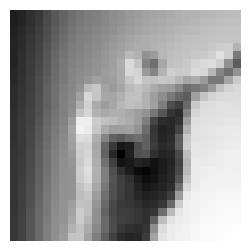

true response: T
predicted:


{'A': 0.0,
 'B': 0.0,
 'C': 0.0,
 'D': 0.0,
 'E': 0.0,
 'F': 0.0,
 'G': 1e-04,
 'H': 0.0,
 'I': 0.0,
 'K': 0.0,
 'L': 0.0,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 0.0,
 'Q': 0.0,
 'R': 0.0,
 'S': 0.0,
 'T': 0.0235,
 'U': 0.0,
 'V': 0.0,
 'W': 0.0,
 'X': 0.9764,
 'Y': 0.0}

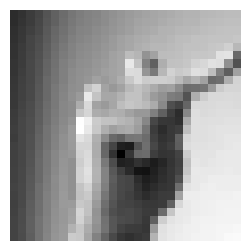

true response: T
predicted:


{'A': 0.0,
 'B': 0.0,
 'C': 0.0,
 'D': 0.0,
 'E': 0.0,
 'F': 0.0,
 'G': 0.0,
 'H': 0.0,
 'I': 0.0,
 'K': 0.0,
 'L': 0.0,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 0.0,
 'Q': 0.0,
 'R': 0.0,
 'S': 0.0,
 'T': 0.005,
 'U': 0.0,
 'V': 0.0,
 'W': 0.0,
 'X': 0.995,
 'Y': 0.0}

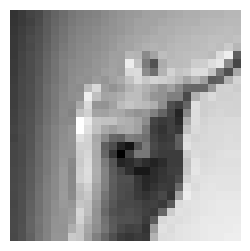

true response: T
predicted:


{'A': 0.0,
 'B': 0.0,
 'C': 0.0,
 'D': 0.0,
 'E': 0.0,
 'F': 0.0,
 'G': 0.0,
 'H': 0.0,
 'I': 0.0,
 'K': 0.0,
 'L': 0.0,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 0.0,
 'Q': 0.0,
 'R': 0.0,
 'S': 0.0,
 'T': 0.006,
 'U': 0.0,
 'V': 0.0,
 'W': 0.0,
 'X': 0.994,
 'Y': 0.0}

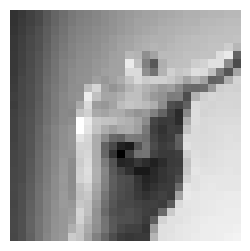

true response: T
predicted:


{'A': 0.0,
 'B': 0.0,
 'C': 0.0,
 'D': 0.0,
 'E': 0.0,
 'F': 0.0,
 'G': 0.0,
 'H': 0.0,
 'I': 0.0,
 'K': 0.0,
 'L': 0.0,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 0.0,
 'Q': 0.0,
 'R': 0.0,
 'S': 0.0,
 'T': 0.0021,
 'U': 0.0,
 'V': 0.0,
 'W': 0.0,
 'X': 0.9979,
 'Y': 0.0}

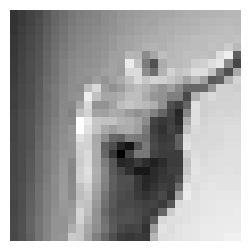

true response: T
predicted:


{'A': 0.0,
 'B': 0.0,
 'C': 0.0,
 'D': 0.0,
 'E': 0.0,
 'F': 0.0,
 'G': 0.0,
 'H': 0.0,
 'I': 0.0,
 'K': 0.0,
 'L': 0.0,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 0.0,
 'Q': 0.0,
 'R': 0.0,
 'S': 0.0,
 'T': 0.0023,
 'U': 0.0,
 'V': 0.0,
 'W': 0.0,
 'X': 0.9977,
 'Y': 0.0}

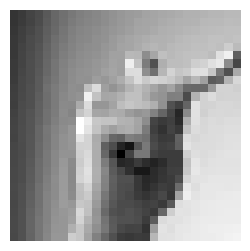

true response: T
predicted:


{'A': 0.0,
 'B': 0.0,
 'C': 0.0,
 'D': 0.0,
 'E': 0.0,
 'F': 0.0,
 'G': 0.0,
 'H': 0.0,
 'I': 0.0,
 'K': 0.0,
 'L': 0.0,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 0.0,
 'Q': 0.0,
 'R': 0.0,
 'S': 0.0,
 'T': 0.0002,
 'U': 0.0,
 'V': 0.0,
 'W': 0.0,
 'X': 0.9998,
 'Y': 0.0}

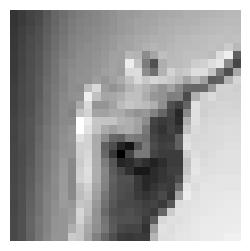

true response: T
predicted:


{'A': 0.0,
 'B': 0.0,
 'C': 0.0,
 'D': 0.0,
 'E': 0.0,
 'F': 0.0,
 'G': 0.0,
 'H': 0.0,
 'I': 0.0,
 'K': 0.0,
 'L': 0.0,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 0.0,
 'Q': 0.0,
 'R': 0.0,
 'S': 0.0,
 'T': 0.0,
 'U': 0.0,
 'V': 0.0,
 'W': 0.0,
 'X': 1.0,
 'Y': 0.0}

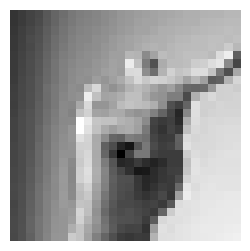

true response: T
predicted:


{'A': 0.0,
 'B': 0.0,
 'C': 0.0,
 'D': 0.0,
 'E': 0.0,
 'F': 0.0,
 'G': 0.0,
 'H': 0.0,
 'I': 0.0,
 'K': 0.0,
 'L': 0.0,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 0.0,
 'Q': 0.0,
 'R': 0.0,
 'S': 0.0,
 'T': 0.0002,
 'U': 0.0,
 'V': 0.0,
 'W': 0.0,
 'X': 0.9998,
 'Y': 0.0}

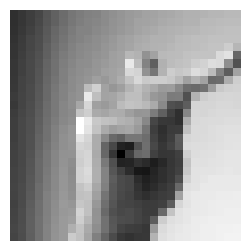

true response: T
predicted:


{'A': 0.0,
 'B': 0.0,
 'C': 0.0,
 'D': 0.0,
 'E': 0.0,
 'F': 0.0,
 'G': 0.0,
 'H': 0.0,
 'I': 0.0,
 'K': 0.0,
 'L': 0.0,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 0.0,
 'Q': 0.0,
 'R': 0.0,
 'S': 0.0,
 'T': 0.003,
 'U': 0.0,
 'V': 0.0,
 'W': 0.0,
 'X': 0.997,
 'Y': 0.0}

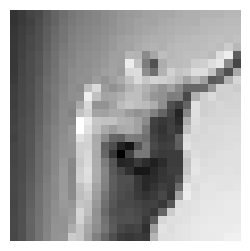

true response: T
predicted:


{'A': 0.0,
 'B': 0.0,
 'C': 0.0,
 'D': 0.0,
 'E': 0.0,
 'F': 0.0,
 'G': 0.0,
 'H': 0.0,
 'I': 0.0,
 'K': 0.0,
 'L': 0.0,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 0.0,
 'Q': 0.0,
 'R': 0.0,
 'S': 0.0,
 'T': 0.0012,
 'U': 0.0,
 'V': 0.0,
 'W': 0.0,
 'X': 0.9988,
 'Y': 0.0}

In [10]:
best_model = NeuralNetwork.load_NN(all_results.iloc[23], classifiers_dict, torch.device("cuda"), (28,28))
best_model.explore_wrong_predictions()

In [11]:
best_model.return_stats()

,epochs,train_losses,eval_losses,test_accuracies,training_time_per_epoch
0,1,0.004352,5.986682e-06,0.979922,1.265330
1,2,0.002461,3.832970e-06,0.986615,1.262679
2,3,0.001804,5.512496e-07,0.995259,1.299065
3,4,0.001356,1.741619e-05,0.988846,1.289462
4,5,0.001541,3.275322e-06,0.984384,1.263963
5,6,0.001125,2.233265e-05,0.982711,1.259491
6,7,0.001029,3.056728e-05,0.987312,1.278851
7,8,0.000829,8.537008e-07,0.987591,1.270695


In [12]:
all_results.sort_values(by=['test_accuracies'], ascending=True).head(10)

,test_id,architecture_id,n_neurons_molt_factor,do_dropout,lr,batch_size,patience,data_augmentation_perc,test_accuracies,test_times,train_times
1,1,0,0.6,['Conv2'],0.0005,32,5,0.25,0.972253,0.091232,7.001711
0,0,0,0.6,['Conv2'],0.0005,32,5,0.00,0.981735,0.080683,30.840531
14,14,0,0.6,['Conv2'],0.0005,32,20,0.50,0.986057,0.083133,40.472305
15,15,0,0.6,['Conv2'],0.0005,32,20,0.75,0.986475,0.081556,121.286708
6,6,0,0.6,['Conv2'],0.0005,32,10,0.50,0.987451,0.082619,55.975638
2,2,0,0.6,['Conv2'],0.0005,32,5,0.50,0.987591,0.080886,14.667440
12,12,0,0.6,['Conv2'],0.0005,32,20,0.00,0.989682,0.083031,15.954947
13,13,0,0.6,['Conv2'],0.0005,32,20,0.25,0.990379,0.082260,19.557499
11,11,0,0.6,['Conv2'],0.0005,32,15,0.75,0.990658,0.083728,94.398274
17,17,0,0.6,['Conv2'],0.0005,64,5,0.25,0.990798,0.059337,4.035670


In [13]:
n_low_accuracy_architectures = len(all_results[all_results["test_accuracies"]==all_results["test_accuracies"].min()])
n_low_accuracy_architectures

1

In [14]:
all_results.sort_values(by=['test_accuracies'], ascending=True).head(n_low_accuracy_architectures)["architecture_id"].unique()

array([0])

In [15]:
architecture_stats(all_results, classifiers_dict, 0)

Stats for architecture: Classifier_3 (n_neurons_molt_factor=0.6, do_dropout=['Conv2']) (id: 0)
mean accuracy: 0.9911 with standard error: 0.0056

worst accuracy: 0.9723 with hyperparameters:
test_id                          1
lr                          0.0005
batch_size                      32
patience                         5
data_augmentation_perc        0.25
test_times                0.091232
train_times               7.001711
Name: 1, dtype: object 

best accuracy: 0.9969 with hyperparameters:
test_id                          22
lr                           0.0005
batch_size                       64
patience                         10
data_augmentation_perc          0.5
test_times                 0.058164
train_times               29.053225
Name: 22, dtype: object 



Loaded model: Classifier_3 (n_neurons_molt_factor=0.6, do_dropout=['Conv2'])_test_0


Architecture:
name: Classifier_3 (n_neurons_molt_factor=0.6, do_dropout=['Conv2'])
Layer (type:depth-idx)                   Output Shape              Param #
├─Sequential: 1-1                        [-1, 32, 12, 12]          --
|    └─Conv2d: 2-1                       [-1, 32, 24, 24]          832
|    └─MaxPool2d: 2-2                    [-1, 32, 12, 12]          --
|    └─ReLU: 2-3                         [-1, 32, 12, 12]          --
├─Sequential: 1-2                        [-1, 64, 4, 4]            --
|    └─Conv2d: 2-4                       [-1, 64, 8, 8]            51,264
|    └─MaxPool2d: 2-5                    [-1, 64, 4, 4]            --
|    └─ReLU: 2-6                         [-1, 64, 4, 4]            --
|    └─Dropout: 2-7                      [-1, 64, 4, 4]            --
├─Sequential: 1-3                        [-1, 128, 1, 1]           --
|    └─Conv2d: 2-8                       [-1, 128, 

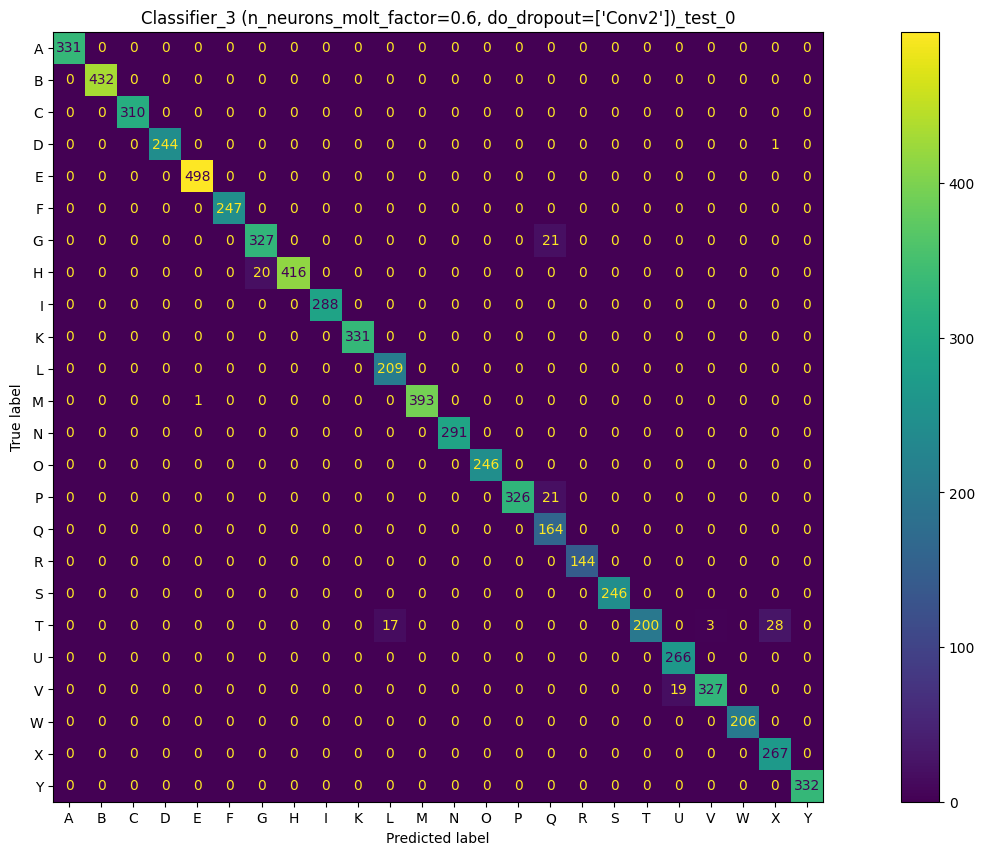

In [16]:
NeuralNetwork.load_NN(all_results.iloc[0], classifiers_dict, torch.device("cuda"), (28,28)).plot_confusion_matrix()

In [17]:
all_results.sort_values(by=['test_accuracies'], ascending=True).iloc[320:330]

,test_id,architecture_id,n_neurons_molt_factor,do_dropout,lr,batch_size,patience,data_augmentation_perc,test_accuracies,test_times,train_times


In [18]:
model = NeuralNetwork.load_NN(all_results.iloc[2880], classifiers_dict, torch.device("cuda"), (28,28))
model.plot_confusion_matrix()

IndexError: single positional indexer is out-of-bounds

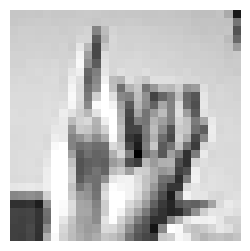

True label: I


{'A': 0.0,
 'B': 0.0,
 'C': 0.0,
 'D': 0.0,
 'E': 0.0,
 'F': 0.0,
 'G': 0.0,
 'H': 0.0,
 'I': 1.0,
 'J': 0.0,
 'K': 0.0,
 'L': 0.0,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 0.0,
 'Q': 0.0,
 'R': 0.0,
 'S': 0.0,
 'T': 0.0,
 'U': 0.0,
 'V': 0.0,
 'W': 0.0,
 'X': 0.0,
 'Y': 0.0}

In [ ]:
image, response = sample_image(index = 10)
best_model.predict(image)